In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv("AB_NYC_2019.csv")

In [22]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [23]:
df.shape

(48895, 16)

In [24]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [26]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [27]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [28]:
df.dtypes

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

In [29]:
# Handle Missing Values
# filling the missing values 'name' and 'host name' as 'unknown'
df['name']= df['name'].fillna('Unknown')
df['host_name']  = df['host_name'].fillna('Unknown')

In [30]:
# Fill missing value 'review_per_month' with '0'safely
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [31]:
# convert the type of  last_review column to datetime
df['last_review'] = pd.to_datetime(df['last_review'])

In [32]:
df.dtypes

id                                         int64
name                                      object
host_id                                    int64
host_name                                 object
neighbourhood_group                       object
neighbourhood                             object
latitude                                 float64
longitude                                float64
room_type                                 object
price                                      int64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[ns]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
dtype: object

In [33]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

<Axes: xlabel='price', ylabel='Count'>

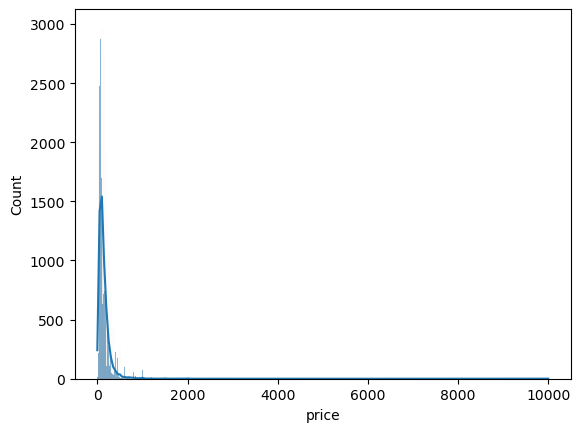

In [34]:
# Check the distibution of the Price 
sns.histplot(data = df , x = 'price', kde = True)

this figre is Right Skewed.Since this data is clearly not normally distributed, do not use the Z-Score method. Instead, use the Interquartile Range (IQR) method.

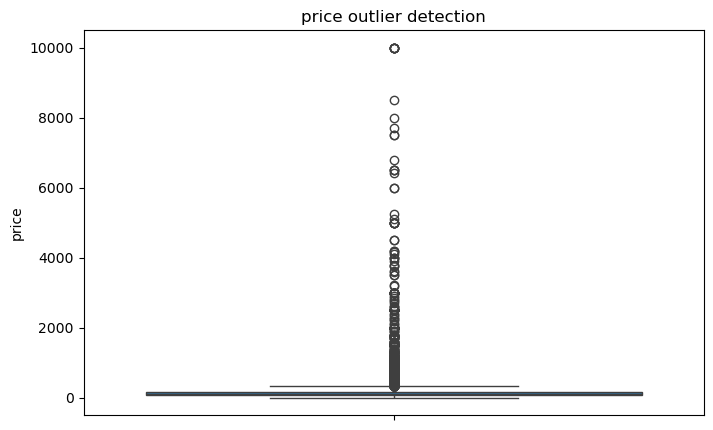

In [35]:
# Detecting Outlier using boxplot
plt.figure(figsize = (8,5))
sns.boxplot(df['price'])

plt.title('price outlier detection')
plt.show()

Outliers in the price column were detected using the Interquartile Range (IQR) method. Extreme price values outside the calculated bounds were filtered to reduce the impact of unusually high listings on the analysis.

In [36]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

In [37]:
IQR = Q3 - Q1

In [38]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [39]:
df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

<Axes: ylabel='price'>

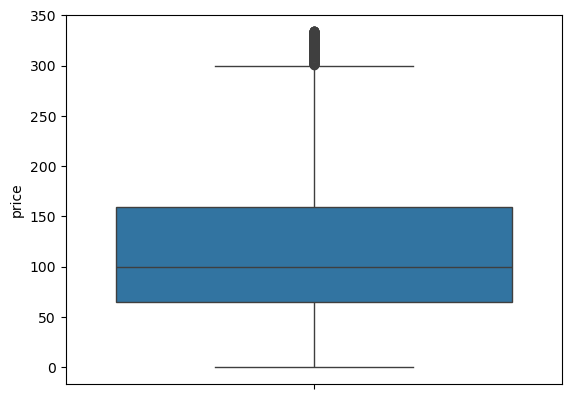

In [40]:
#After Removing the outliers
sns.boxplot(df['price'])

In [41]:
df.shape

(45923, 16)

## Neighbourhood Popularity

In [42]:
df['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        19506
Brooklyn         19415
Queens            5567
Bronx             1070
Staten Island      365
Name: count, dtype: int64

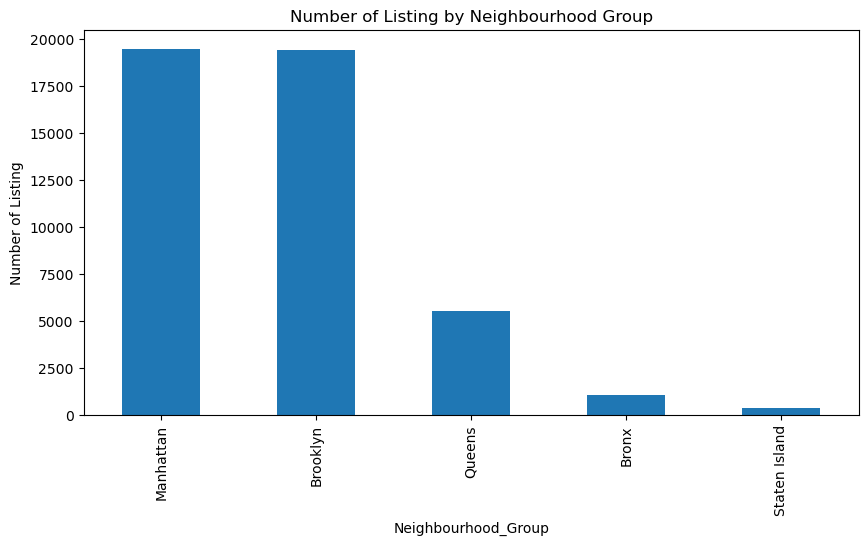

In [43]:
#Which neighbourhood groups have the highest number of listings?
df['neighbourhood_group'].value_counts().plot(kind = 'bar' , figsize = (10,5))

plt.title("Number of Listing by Neighbourhood Group")
plt.xlabel("Neighbourhood_Group")
plt.ylabel("Number of Listing")
plt.show()

## Room Type of distribution

In [44]:
df['room_type'].value_counts()

room_type
Entire home/apt    22789
Private room       21996
Shared room         1138
Name: count, dtype: int64

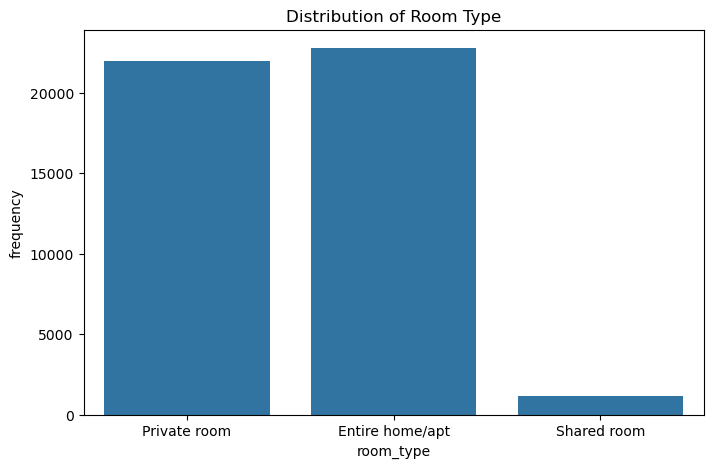

In [45]:
plt.figure(figsize= (8,5))

sns.countplot(data = df , x = 'room_type')
plt.title("Distribution of Room Type")
plt.ylabel('frequency')
plt.show()

## Price Distribution Analysis

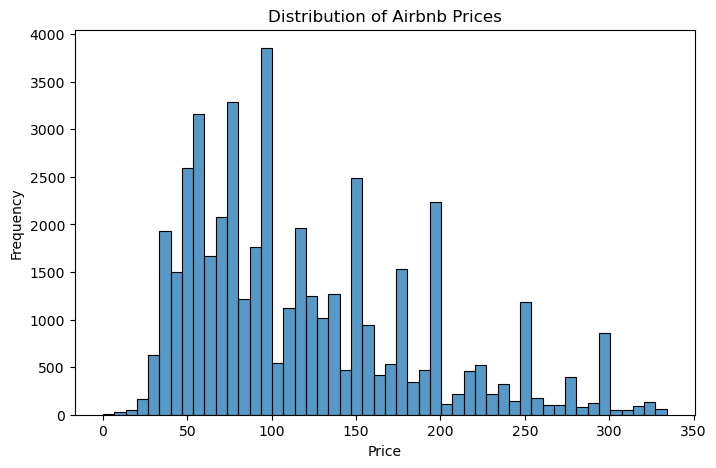

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(data = df , x = 'price',bins = 50)
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## Price VS Room Type

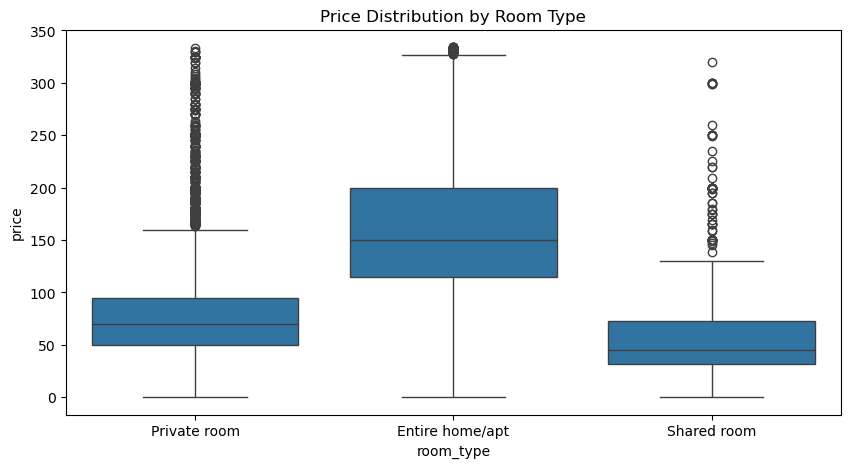

In [47]:
plt.figure(figsize=(10,5))

sns.boxplot(data = df , x = 'room_type', y = 'price')
plt.title('Price Distribution by Room Type')
plt.show()


## Top Expensive Neighbourhood_groups

In [48]:
 ##Price BY Neighbourhood_group
df.groupby("neighbourhood_group")['price'].mean().sort_values(ascending = False)

neighbourhood_group
Manhattan        145.952835
Brooklyn         105.699614
Staten Island     89.235616
Queens            88.904437
Bronx             77.365421
Name: price, dtype: float64

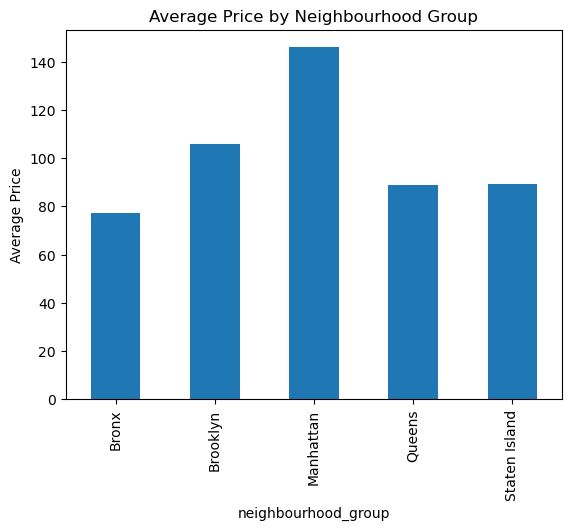

In [49]:
df.groupby("neighbourhood_group")['price'].mean().plot(kind = 'bar')
plt.title("Average Price by Neighbourhood Group")
plt.ylabel("Average Price")
plt.show()

## Review vs Price

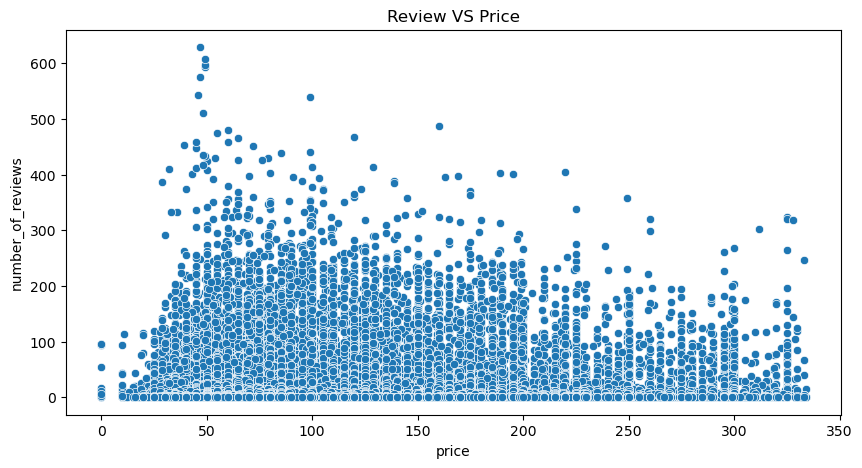

In [50]:
plt.figure(figsize = (10,5))

sns.scatterplot(data = df , x = 'price' , y = 'number_of_reviews')
plt.title("Review VS Price")
plt.show()

## Availability Analysis

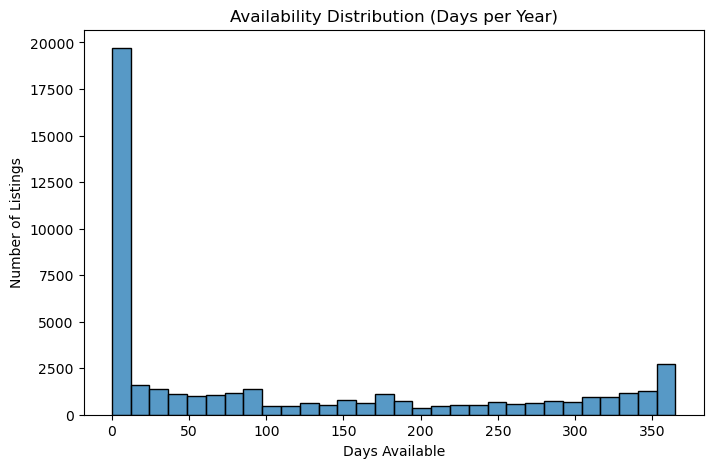

In [51]:
plt.figure(figsize = (8,5))

sns.histplot(data = df , x = 'availability_365' , bins = 30)
plt.title("Availability Distribution (Days per Year)")
plt.xlabel("Days Available")
plt.ylabel("Number of Listings")
plt.show()

## Correlation Heatmap

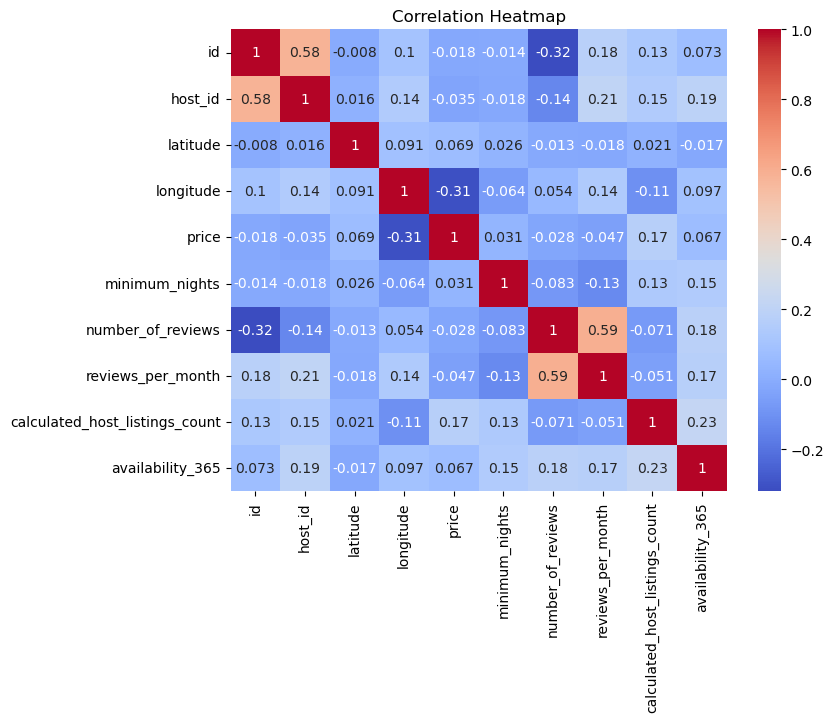

In [52]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [53]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [54]:
df.shape

(45923, 16)

## connect data to mysql

In [55]:
!pip install pymysql sqlalchemy

In [56]:
from sqlalchemy import create_engine

# MySQL connection
username = "root"
password = "Sumit123"
host = "localhost"
port = "3306"
database = "Airbnbdata"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Write DataFrame to MySQL
table_name = "airbnb"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

# Read back sample
pd.read_sql("SELECT * FROM airbnb LIMIT 5;", engine)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [57]:
df.shape

(45923, 16)